# GP-Bayesian Operator Inference: Burgers Equation

**Workflow:**
1. Generate training data and fit POD basis
2. Fit GP hyperparameters
3. Compute operator via GP-derivative regression
4. Run Bayesian inference (SVI with AutoNormal)
5. Evaluate and visualize results

## 1. Setup and Configuration

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import jax
import jax.numpy as jnp
import opinf
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist

from core import (
    generate_trajectory,
    JaxCompatibleModel,
    fit_gp_hyperparameters_mle,
    compute_gp_derivatives,
    build_bayesian_opinf_model,
    run_svi,
    generate_rom_predictions,
    plot_deterministic_rom_solves,
    plot_gp_fit,
    plot_operator_derivative_fit,
    plot_full_order_error,
    save_paper_figure,
    Plotter,
    run_diagnostics,
    diagnose_stability,
    DataScaler,
)
import config
from config import Basis, ReducedOrderModel

numpyro.set_platform('cpu')
numpyro.set_host_device_count(4)

np.random.seed(42)
rng_key = jax.random.PRNGKey(42)

In [2]:
# === EXPERIMENT CONFIGURATION ===
OPERATORS = "cAH"          # OpInf operator structure (no inputs)
NUM_MODES = 10              # POD modes to retain

# Data generation
TRAINING_SPAN = (0, 0.7)   # Train on first 70% of time domain
PREDICTION_SPAN = (0, 1.0)  # Predict full domain
NUM_SAMPLES = 300            # Training samples
NOISE_LEVEL = 0.01
NUM_EVAL_POINTS = None
LS_BOUNDS = (0.01, 1.5)
IVP_METHOD = "RK45"

USE_SCALED_DATA = False

# Inference
RUN_SVI = True
GUIDE = numpyro.infer.autoguide.AutoNormal
VERBOSE = True

# Hyperparameters
GAMMA = 1e-1
GAMMA2 = 1e-1
RELATIVE_GAMMA2 = False

# Paper figures
SAVE_PAPER_FIGURES = False
PAPER_SCENARIO = "burgers"
PAPER_FIGURES_DIR = "../../GP-Bayes-Refactor/figures/manu"

## 2. Generate Training Data

In [3]:
(fom, time_domain_full, true_states, time_sampled, snapshots_sampled) = \
    generate_trajectory(config, np.linspace(*PREDICTION_SPAN, 801), TRAINING_SPAN, NUM_SAMPLES, NOISE_LEVEL)

print(f"Full time domain: {time_domain_full.shape}")
print(f"True states: {true_states.shape}")
print(f"Sampled times: {time_sampled.shape}")
print(f"Sampled snapshots: {snapshots_sampled.shape}")

generating training data...done in 0.22 s.
Full time domain: (801,)
True states: (256, 801)
Sampled times: (300,)
Sampled snapshots: (256, 300)


In [4]:
basis = opinf.basis.PODBasis(num_vectors=NUM_MODES)
basis.fit(snapshots_sampled)

snapshots_comp_sampled = basis.compress(snapshots_sampled)
full_states_compressed = basis.compress(true_states)
print(f"Compressed shape: {snapshots_comp_sampled.shape}")
print(f"Cumulative energy: {basis.cumulative_energy:.4%}")

Compressed shape: (10, 300)
Cumulative energy: 99.9913%


In [5]:
NUM_REGRESSION_POINTS = 150
time_domain_eval_training = np.linspace(TRAINING_SPAN[0], TRAINING_SPAN[1], NUM_REGRESSION_POINTS)
time_domain_eval_prediction = np.linspace(PREDICTION_SPAN[0], PREDICTION_SPAN[1], NUM_REGRESSION_POINTS)
time_domain_full = np.linspace(*PREDICTION_SPAN, true_states.shape[1])

## 2a. Data Scaling

In [6]:
if USE_SCALED_DATA:
    data_scaler = DataScaler(num_modes=NUM_MODES)
    data_scaler.fit(snapshots_comp_sampled)
    training_data = data_scaler.transform(snapshots_comp_sampled)
    print(f"Scaling enabled: {data_scaler}")
else:
    data_scaler = None
    training_data = snapshots_comp_sampled
    print("Scaling disabled")

Scaling disabled


In [7]:
from core.bayesian_opinf import JaxCompatibleModel

model = JaxCompatibleModel(operators=OPERATORS)
rom = opinf.ROM(
    basis=basis,
    model=model,
    ddt_estimator=opinf.ddt.NonuniformFiniteDifferencer(time_sampled),
)
rom.fit(states=snapshots_sampled)
print(f"ROM initialized: {OPERATORS}")
print(f"Operator matrix shape: {rom.model.operator_matrix.shape}")

ROM initialized: cAH
Operator matrix shape: (10, 66)


## 3. Fit GP Hyperparameters

In [8]:
import time

start_time = time.time()
total_plot_time = 0

In [9]:
Ls, Vs, Ns, gp_models = fit_gp_hyperparameters_mle(
    time_domain=time_sampled,
    snapshots=training_data,
    verbose=VERBOSE,
    lengthscale_bounds=LS_BOUNDS,
)

Fitting GP hyperparameters via MLE...
  Lengthscale bounds: [0.0100, 1.5000]
  L=0.1853, V=17.6960, N=0.000036
  Mode 0: L=0.1853, V=17.6960, N=0.000036
  L=0.1376, V=3.9747, N=0.000037
  Mode 1: L=0.1376, V=3.9747, N=0.000037
  L=0.1175, V=1.0280, N=0.000029
  Mode 2: L=0.1175, V=1.0280, N=0.000029
  L=0.1007, V=0.2159, N=0.000034
  Mode 3: L=0.1007, V=0.2159, N=0.000034
  L=0.0607, V=0.0127, N=0.000037
  Mode 4: L=0.0607, V=0.0127, N=0.000037
  L=0.6343, V=0.0000, N=0.000145
  Mode 5: L=0.6343, V=0.0000, N=0.000145
  L=1.4998, V=0.0000, N=0.000137
  Mode 6: L=1.4998, V=0.0000, N=0.000137
  L=1.5000, V=0.0000, N=0.000131
  Mode 7: L=1.5000, V=0.0000, N=0.000131
  L=0.6666, V=0.0000, N=0.000127
  Mode 8: L=0.6666, V=0.0000, N=0.000127
  L=1.0544, V=0.0000, N=0.000122
  Mode 9: L=1.0544, V=0.0000, N=0.000122


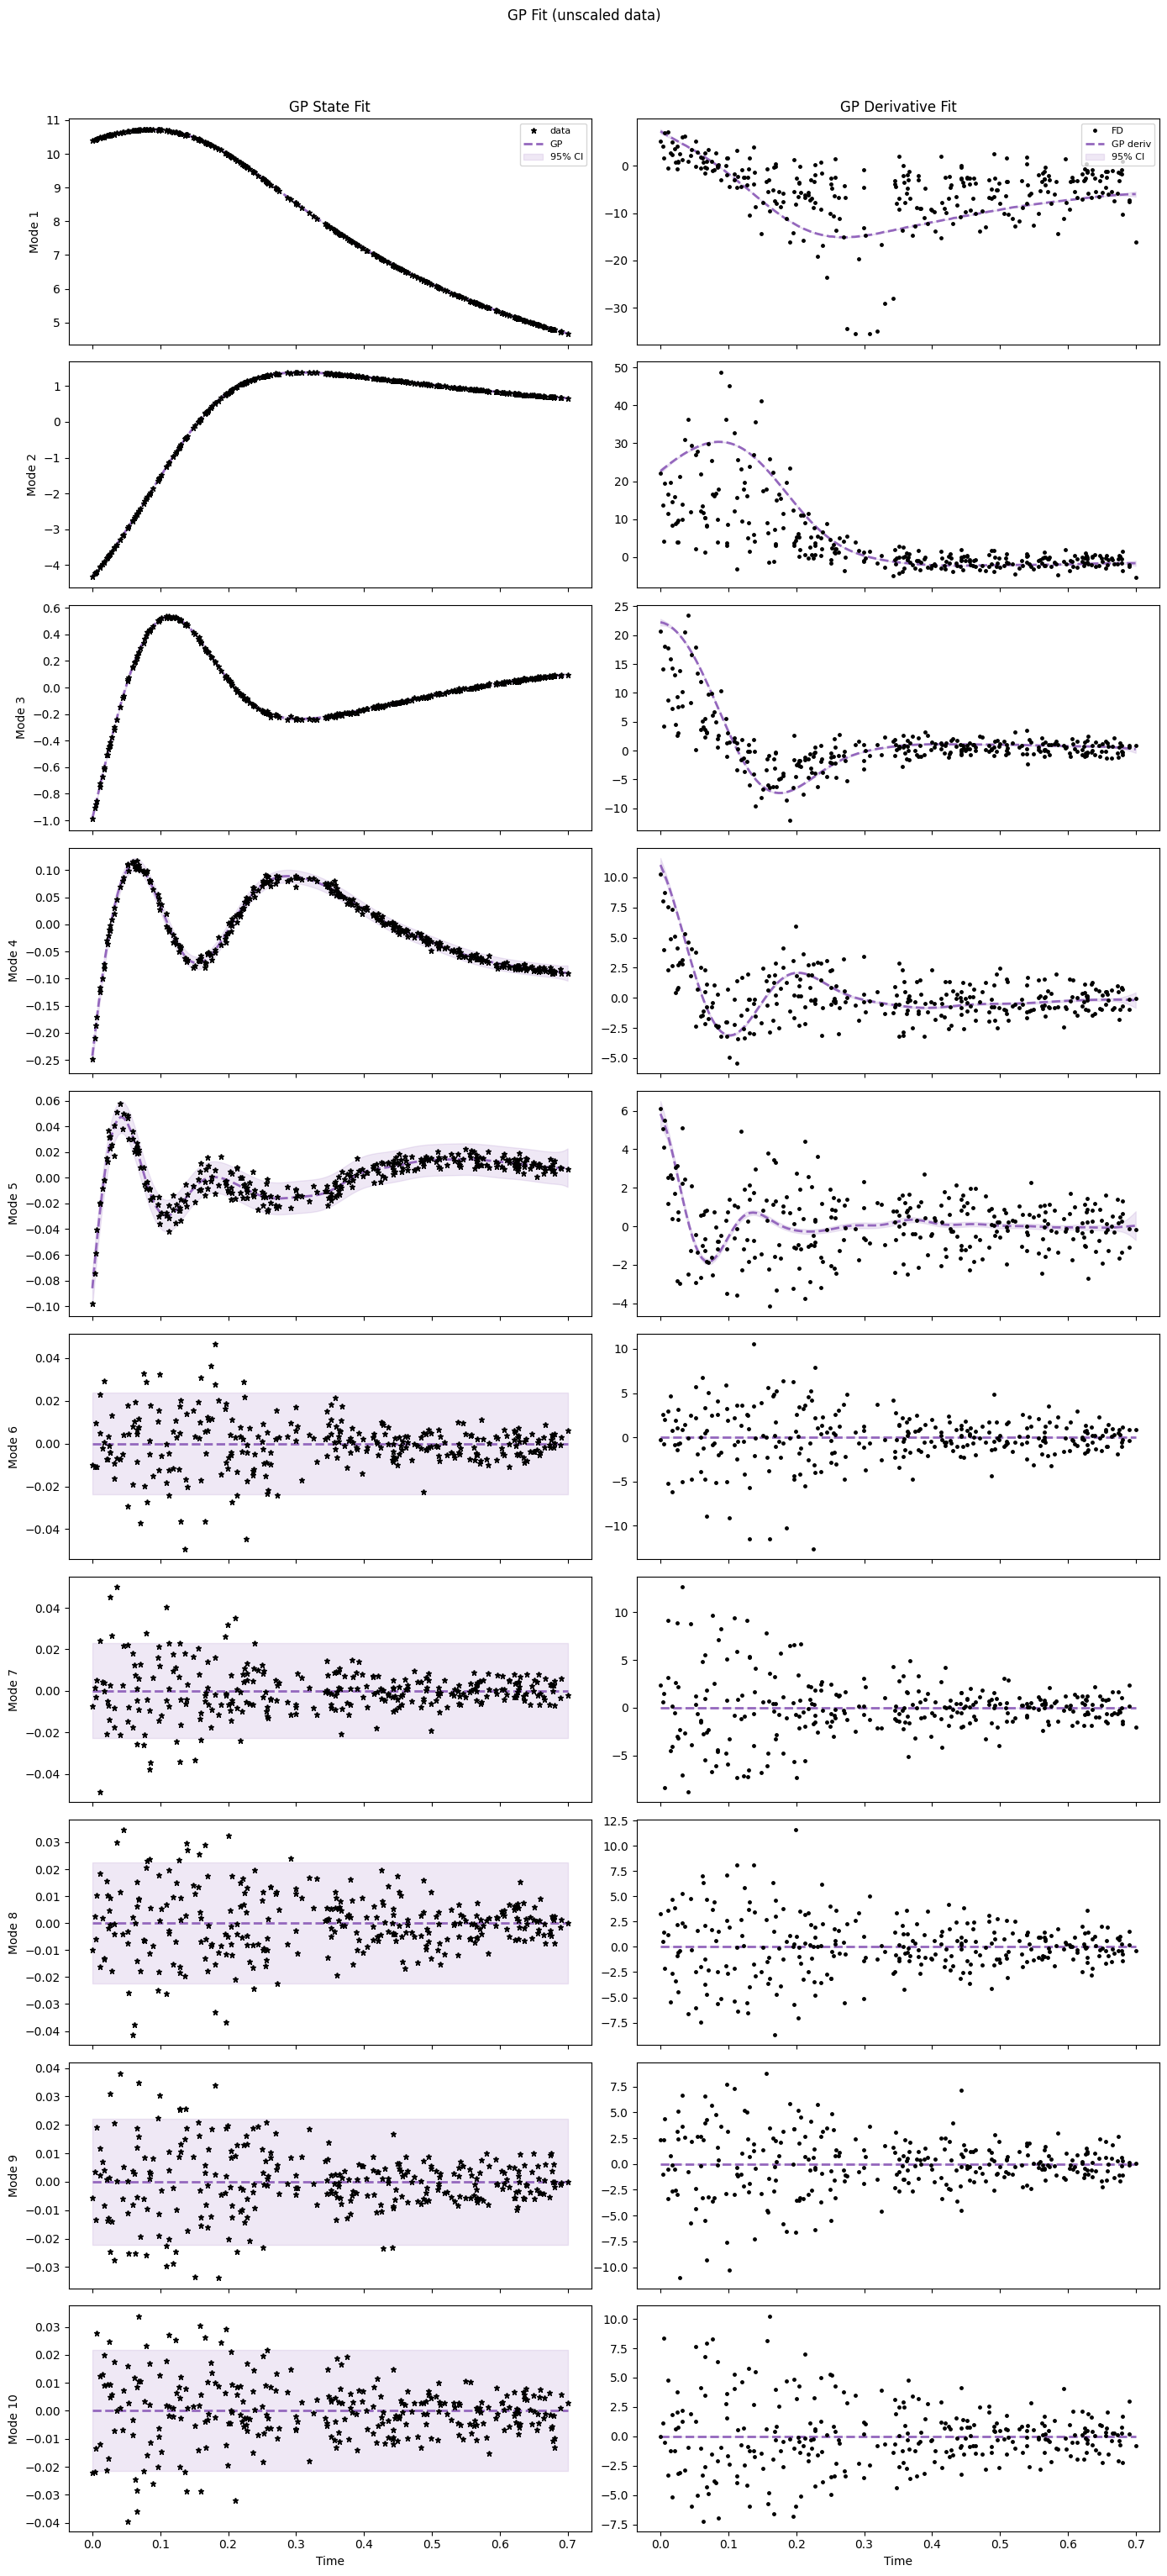

In [10]:
_plot_t0 = time.time()
fig, axes = plot_gp_fit(
    gp_models=gp_models,
    snapshots_compressed=training_data,
    time_sampled=time_sampled,
    time_eval=time_domain_eval_training,
    lengthscales=Ls,
    variances=Vs,
    plot_derivatives=True,
)
plt.suptitle(f"GP Fit ({'scaled' if USE_SCALED_DATA else 'unscaled'} data)", y=1.02)
plt.show()
total_plot_time += time.time() - _plot_t0

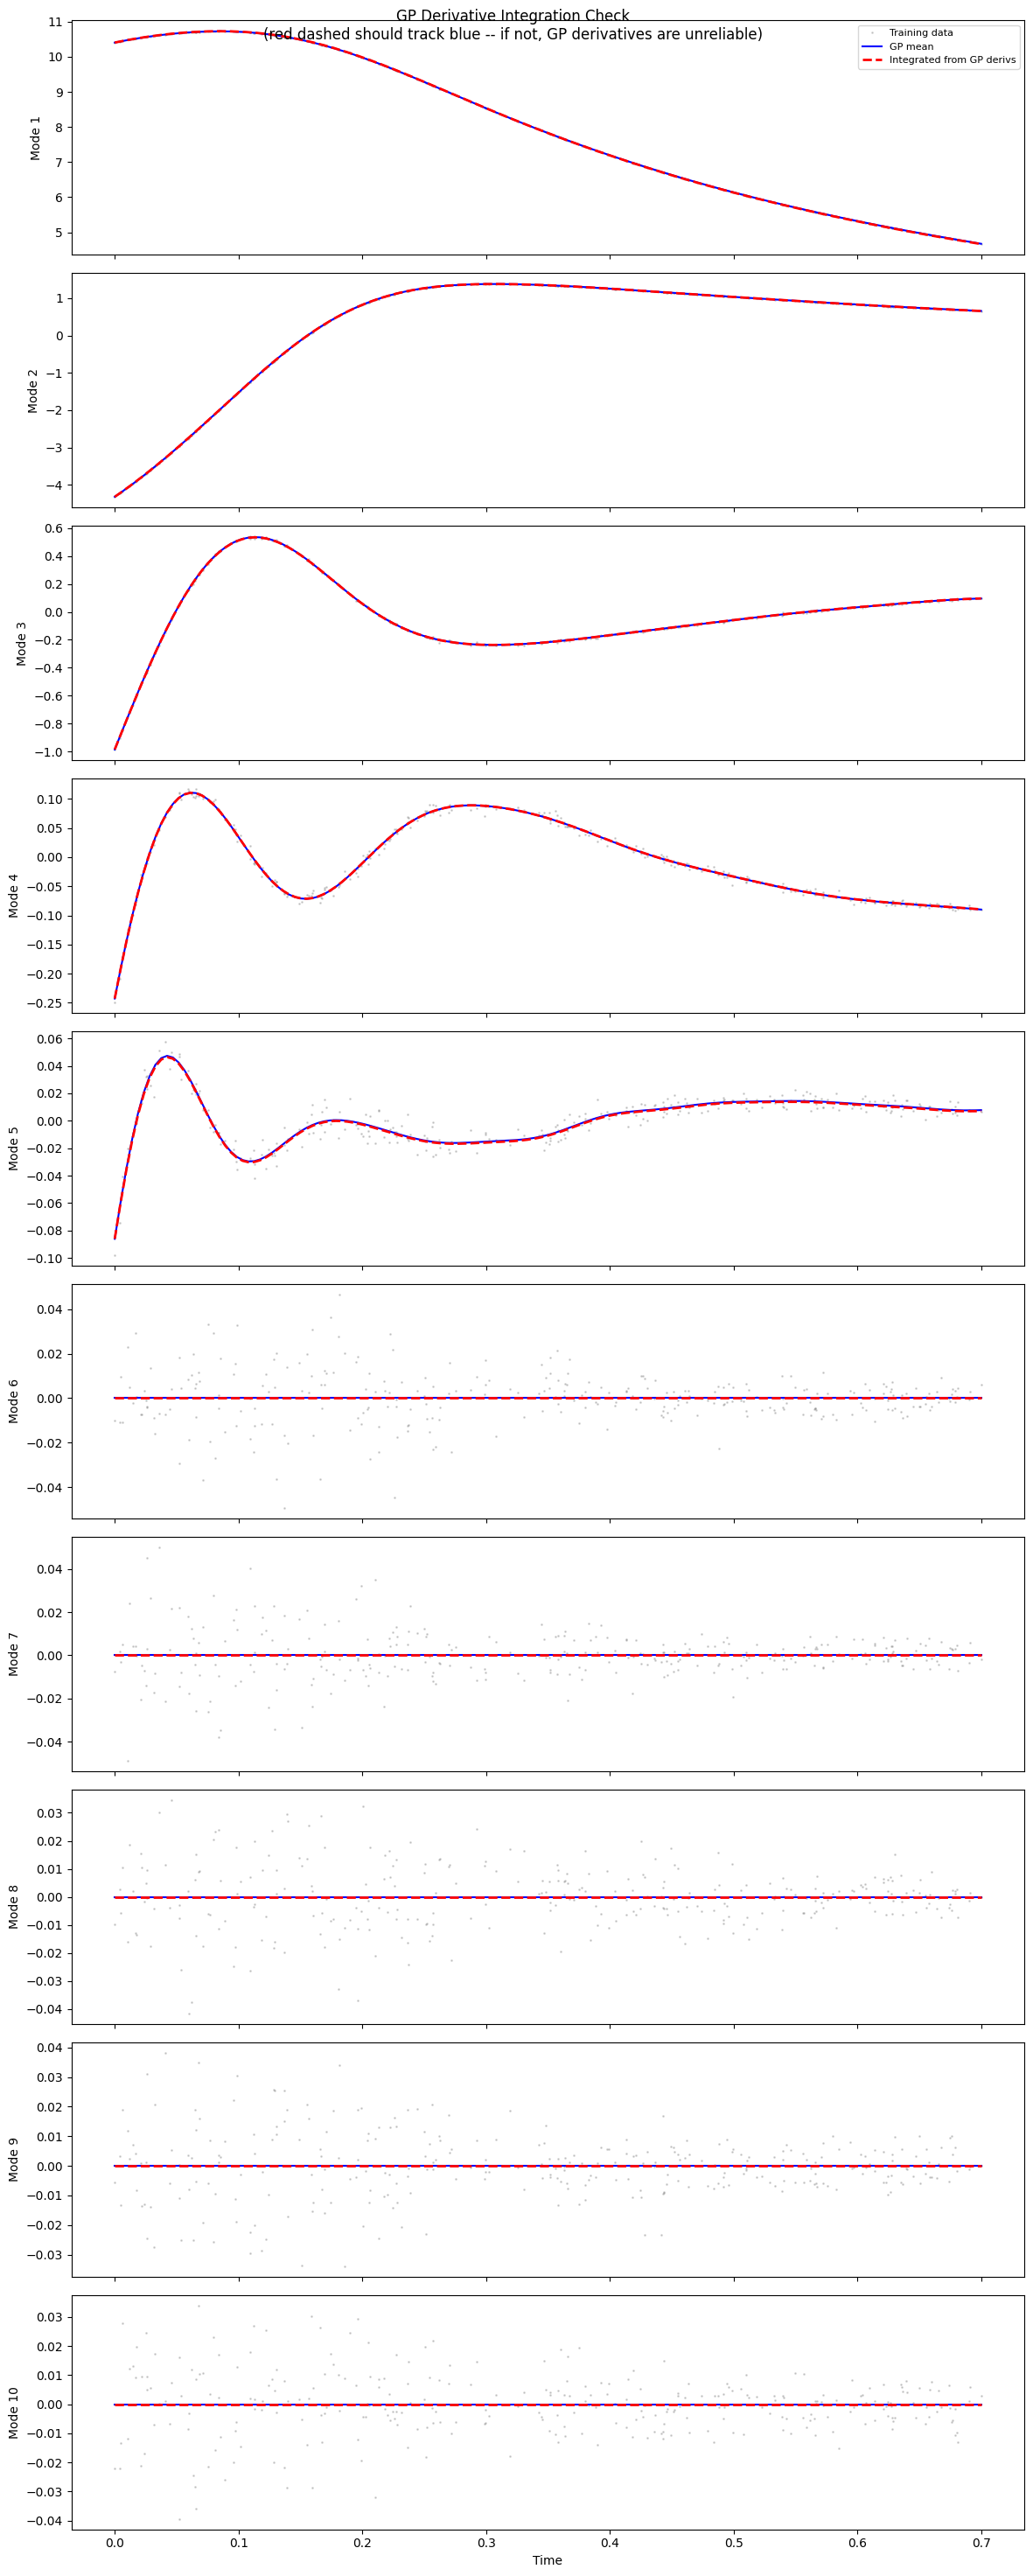

  Mode 1: relative L2 integration error = 0.0006
  Mode 2: relative L2 integration error = 0.0008
  Mode 3: relative L2 integration error = 0.0020
  Mode 4: relative L2 integration error = 0.0021
  Mode 5: relative L2 integration error = 0.0359
  Mode 6: relative L2 integration error = 0.0483
  Mode 7: relative L2 integration error = 0.0173
  Mode 8: relative L2 integration error = 0.0103
  Mode 9: relative L2 integration error = 0.0392
  Mode 10: relative L2 integration error = 0.0198


In [11]:
from scipy.integrate import cumulative_trapezoid

t_dense = time_domain_eval_training

gp_means = np.array([
    gp_models[i].predict(t_dense[:, None], return_std=False)
    for i in range(NUM_MODES)
])

mu_z_check, _ = compute_gp_derivatives(
    Ls, Vs, time_sampled, t_dense, training_data, Ns=Ns
)

q_integrated = np.zeros_like(gp_means)
for i in range(NUM_MODES):
    q0 = gp_means[i, 0]
    q_integrated[i, 1:] = q0 + cumulative_trapezoid(np.array(mu_z_check[i]), t_dense)
    q_integrated[i, 0] = q0

if USE_SCALED_DATA:
    gp_means_orig = data_scaler.inverse_transform(gp_means)
    q_integrated_orig = data_scaler.inverse_transform(q_integrated)
    data_label = "GP mean (scaled -> original)"
else:
    gp_means_orig = gp_means
    q_integrated_orig = q_integrated
    data_label = "GP mean"

fig, axes = plt.subplots(NUM_MODES, 1, figsize=(12, 3 * NUM_MODES), sharex=True)
if NUM_MODES == 1:
    axes = [axes]

for i in range(NUM_MODES):
    ax = axes[i]
    ax.plot(time_sampled, snapshots_comp_sampled[i], '.', color='gray',
            alpha=0.3, markersize=2, label='Training data')
    ax.plot(t_dense, gp_means_orig[i], 'b-', lw=1.5, label=data_label)
    ax.plot(t_dense, q_integrated_orig[i], 'r--', lw=2, label='Integrated from GP derivs')
    ax.set_ylabel(f"Mode {i+1}")
    if i == 0:
        ax.legend(fontsize=8)

axes[-1].set_xlabel("Time")
fig.suptitle("GP Derivative Integration Check\n"
             "(red dashed should track blue -- if not, GP derivatives are unreliable)",
             fontsize=12)
plt.tight_layout()
plt.show()

for i in range(NUM_MODES):
    l2_err = np.linalg.norm(q_integrated_orig[i] - gp_means_orig[i]) / np.linalg.norm(gp_means_orig[i])
    print(f"  Mode {i+1}: relative L2 integration error = {l2_err:.4f}")

## 3a. GP-Derivative Operator

Best operator: reg=5.62e+00, traj_err=0.0054, deriv_res=0.0286
Operator shape: (10, 66)


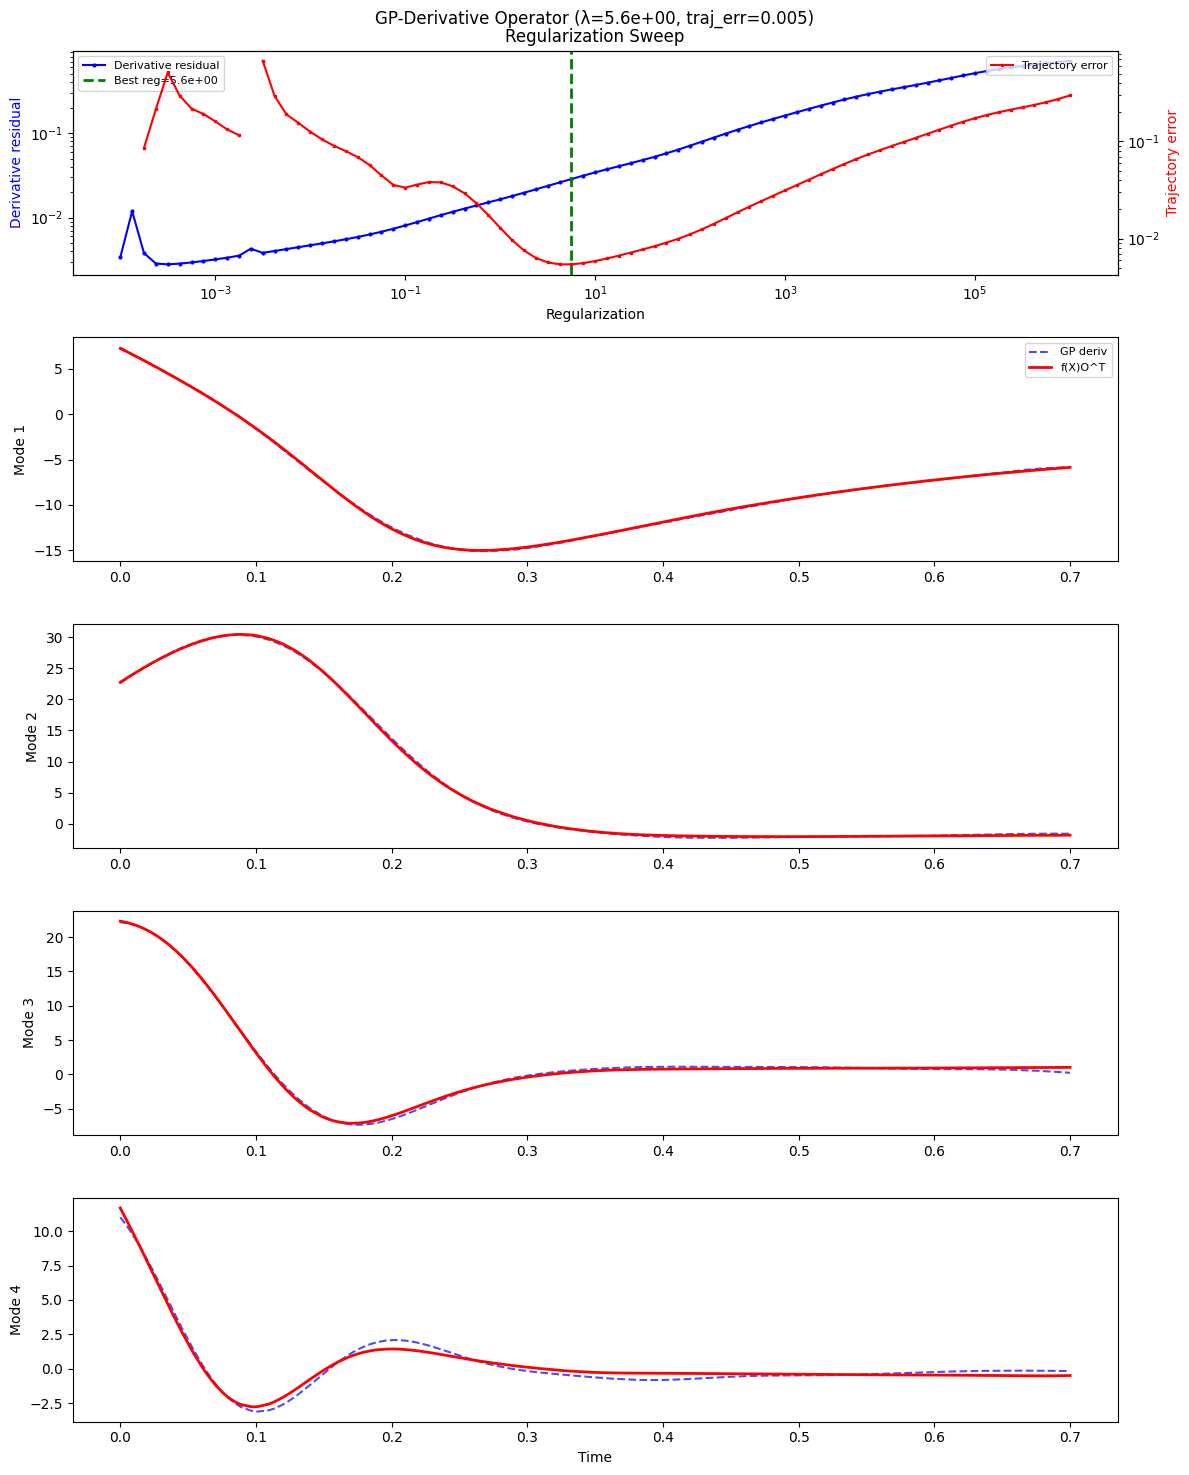

In [12]:
from core.bayesian_opinf import compute_gp_derivatives

gp_states = np.array([
    gp_models[i].predict(time_sampled[:, None], return_std=False)
    for i in range(NUM_MODES)
])

mu_z_gp, _ = compute_gp_derivatives(
    Ls, Vs, time_sampled, time_sampled, training_data, Ns=Ns
)

if USE_SCALED_DATA and data_scaler is not None:
    gp_states_orig = data_scaler.inverse_transform(gp_states)
    mu_z_orig = data_scaler.unscale_derivatives(mu_z_gp)
else:
    gp_states_orig = gp_states
    mu_z_orig = mu_z_gp

# Build data matrix — no inputs for Burgers
D = rom.model._assemble_data_matrix(jnp.array(gp_states_orig), None)
D_np = np.array(D)
target = np.array(mu_z_orig).T

# Truth for trajectory comparison
t_eval_reg = np.linspace(TRAINING_SPAN[0], TRAINING_SPAN[1], 150)
t_truth = np.linspace(*PREDICTION_SPAN, true_states.shape[1])
truth_at_eval = np.array([
    np.interp(t_eval_reg, t_truth, full_states_compressed[i])
    for i in range(NUM_MODES)
])
q0 = snapshots_comp_sampled[:, 0]

# Sweep regularization: select by trajectory error
reg_values = np.logspace(-4, 6, 81)
best_reg, best_traj_err, best_O = None, np.inf, None
best_deriv_res = None
results_log = []

for reg in reg_values:
    O_candidate = np.linalg.solve(
        D_np.T @ D_np + reg * np.eye(D_np.shape[1]),
        D_np.T @ target
    ).T
    deriv_res = np.linalg.norm(D_np @ O_candidate.T - target) / np.linalg.norm(target)

    rom.model._extract_operators(np.array(O_candidate))
    try:
        rom.model.predict(state0=q0, t=t_eval_reg, input_func=None, method=IVP_METHOD)
        res = rom.model.predict_result_
        if res.success and res.t.shape[0] == len(t_eval_reg):
            traj_err = np.linalg.norm(res.y - truth_at_eval) / np.linalg.norm(truth_at_eval)
        else:
            traj_err = np.inf
    except Exception:
        traj_err = np.inf

    results_log.append((reg, deriv_res, traj_err))
    if traj_err < best_traj_err:
        best_traj_err = traj_err
        best_reg = reg
        best_O = O_candidate.copy()
        best_deriv_res = deriv_res

prior_operator = best_O
print(f"Best operator: reg={best_reg:.2e}, traj_err={best_traj_err:.4f}, deriv_res={best_deriv_res:.4f}")
print(f"Operator shape: {prior_operator.shape}")

# Plot sweep + derivative fit
fig, axes = plt.subplots(min(NUM_MODES, 4) + 1, 1, figsize=(12, 3 * (min(NUM_MODES, 4) + 1)), sharex=False)
regs, d_res, t_err = zip(*results_log)
ax0 = axes[0]
ax0.loglog(regs, d_res, 'b-o', markersize=2, label='Derivative residual')
ax0_r = ax0.twinx()
t_err_plot = [e if e < 10 else np.nan for e in t_err]
ax0_r.semilogy(regs, t_err_plot, 'r-s', markersize=2, label='Trajectory error')
ax0.axvline(best_reg, color='green', ls='--', lw=2, label=f'Best reg={best_reg:.1e}')
ax0.set_xlabel('Regularization')
ax0.set_ylabel('Derivative residual', color='b')
ax0_r.set_ylabel('Trajectory error', color='r')
ax0.legend(loc='upper left', fontsize=8)
ax0_r.legend(loc='upper right', fontsize=8)
ax0.set_title('Regularization Sweep')

pred_derivs = (D_np @ best_O.T).T
for idx in range(min(NUM_MODES, 4)):
    ax = axes[idx + 1]
    ax.plot(time_sampled, np.array(mu_z_orig)[idx], 'b--', lw=1.5, alpha=0.7, label='GP deriv')
    ax.plot(time_sampled, pred_derivs[idx], 'r-', lw=2, label='f(X)O^T')
    ax.set_ylabel(f'Mode {idx+1}')
    if idx == 0: ax.legend(fontsize=8)
axes[-1].set_xlabel('Time')
fig.suptitle(f'GP-Derivative Operator (\u03bb={best_reg:.1e}, traj_err={best_traj_err:.3f})')
plt.tight_layout()
plt.show()

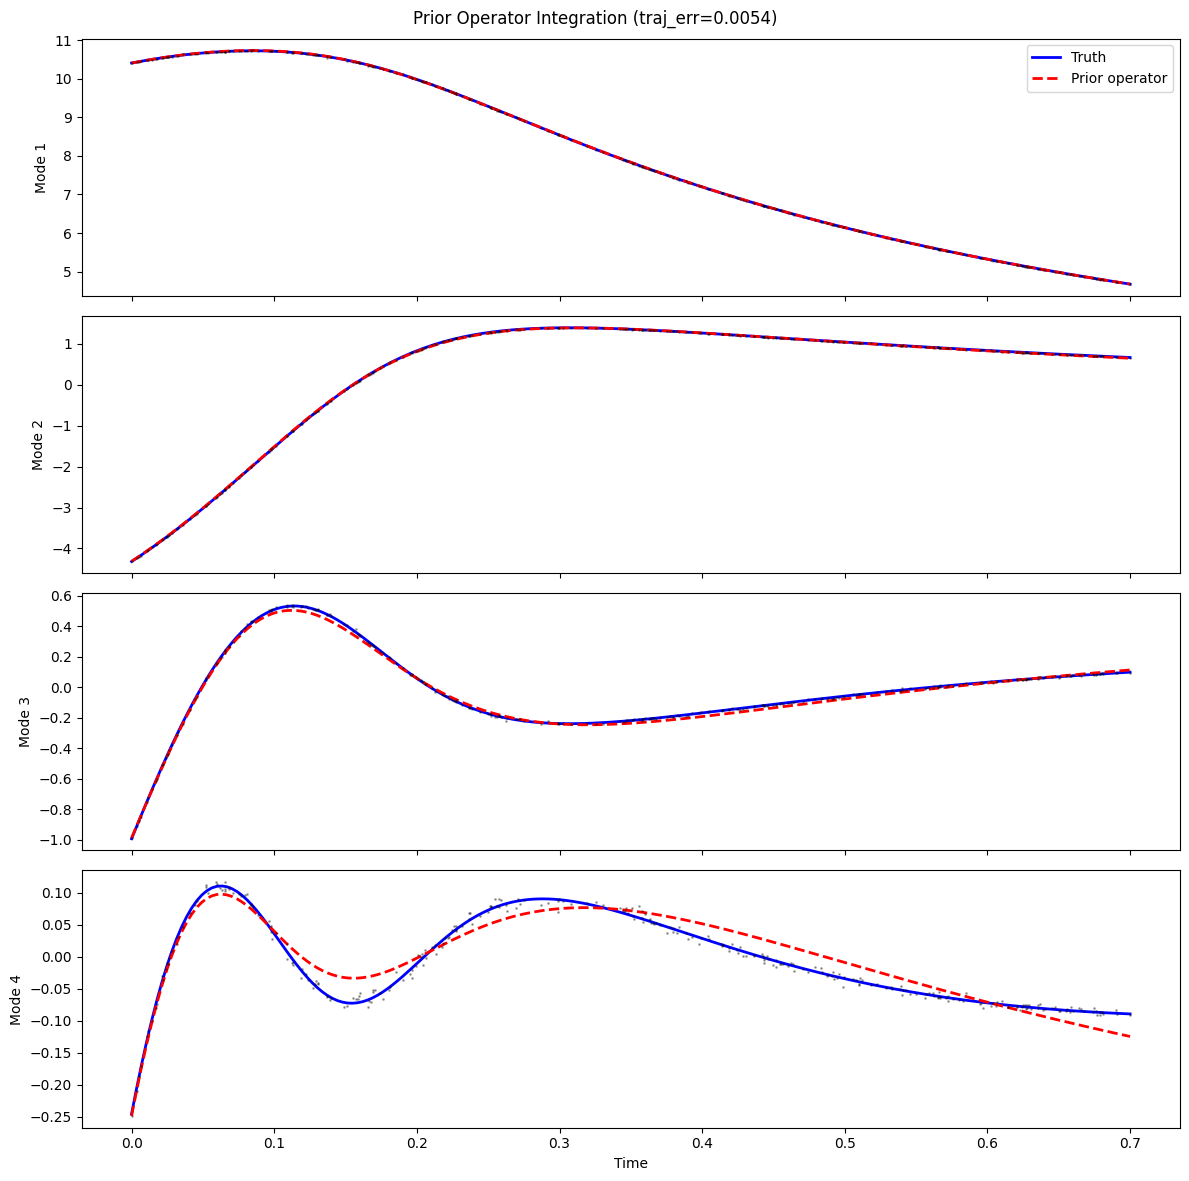

In [13]:
rom.model._extract_operators(np.array(prior_operator))
q0 = snapshots_comp_sampled[:, 0]
t_check = np.linspace(TRAINING_SPAN[0], TRAINING_SPAN[1], 200)
rom.model.predict(state0=q0, t=t_check, input_func=None, method=IVP_METHOD)
res = rom.model.predict_result_

fig, axes = plt.subplots(min(NUM_MODES, 4), 1, figsize=(12, 3 * min(NUM_MODES, 4)), sharex=True)
if min(NUM_MODES, 4) == 1: axes = [axes]
t_truth = np.linspace(*PREDICTION_SPAN, true_states.shape[1])
for i in range(min(NUM_MODES, 4)):
    truth_interp = np.interp(t_check, t_truth, full_states_compressed[i])
    axes[i].plot(t_check, truth_interp, 'b-', lw=2, label='Truth')
    axes[i].plot(res.t, res.y[i], 'r--', lw=2, label='Prior operator')
    axes[i].plot(time_sampled, snapshots_comp_sampled[i], 'k.', alpha=0.3, markersize=2)
    axes[i].set_ylabel(f'Mode {i+1}')
    if i == 0: axes[i].legend()
axes[-1].set_xlabel('Time')
traj_err = np.linalg.norm(res.y - np.array([np.interp(t_check, t_truth, full_states_compressed[i]) for i in range(NUM_MODES)])) / np.linalg.norm(np.array([np.interp(t_check, t_truth, full_states_compressed[i]) for i in range(NUM_MODES)]))
fig.suptitle(f'Prior Operator Integration (traj_err={traj_err:.4f})')
plt.tight_layout()
plt.show()

## 4. Bayesian Inference

In [14]:
if NUM_EVAL_POINTS is not None:
    time_eval = np.linspace(time_sampled[0], time_sampled[-1], NUM_EVAL_POINTS)
else:
    time_eval = time_sampled

Xs_means = np.array([
    gp_models[i].predict(time_eval[:, None], return_std=False)
    for i in range(NUM_MODES)
])

bayesian_opinf_model = build_bayesian_opinf_model(
    prior_operator=prior_operator,
    rom=rom,
    Ls_means=Ls,
    Vs_means=Vs,
    time_domain_sampled=time_sampled,
    snapshots=training_data,
    Xs_means=Xs_means,
    Ns_means=Ns,
    inputs_eval=None,
    data_scaler=data_scaler if USE_SCALED_DATA else None,
    relative_gamma=True,
    relative_gamma2=RELATIVE_GAMMA2,
    reparam="shifted",
    svi_O_mean=jnp.array(prior_operator),
    svi_O_std=jnp.ones_like(jnp.array(prior_operator)) * GAMMA,
    min_absolute_std=1e-2,
    min_relative_std=0.0,
)
print("Bayesian model built")

Bayesian model built


Running SVI (gamma=0.1, gamma2=0.1)...


100%|██████████| 100000/100000 [13:57<00:00, 119.44it/s, init loss: 6891.1309, avg. loss [95001-100000]: -173.4706]


✅ SVI complete! Final loss: -178.7298
   Sample keys: ['O', 'O_standardized', 'X0_0', 'X0_1', 'X0_2', 'X0_3', 'X0_4', 'X0_5', 'X0_6', 'X0_7', 'X0_8', 'X0_9', 'ode_constraint0_0', 'ode_constraint0_1', 'ode_constraint0_2', 'ode_constraint0_3', 'ode_constraint0_4', 'ode_constraint0_5', 'ode_constraint0_6', 'ode_constraint0_7', 'ode_constraint0_8', 'ode_constraint0_9']
SVI operator extracted from key 'O', shape: (10, 66)


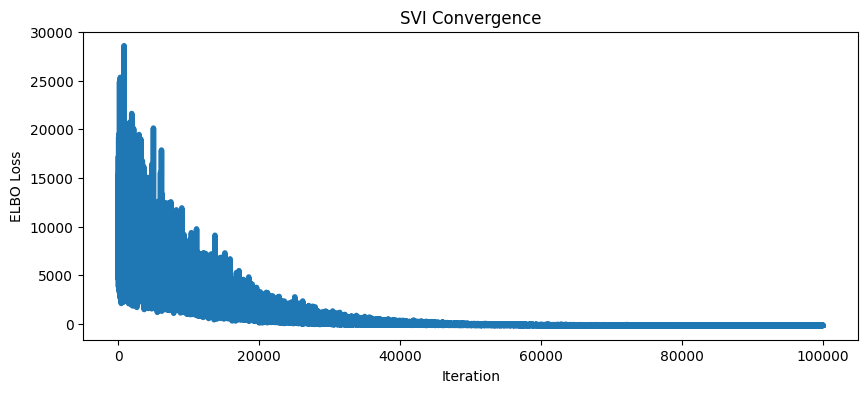

In [15]:
from functools import partial
from numpyro.infer import init_to_value

if RUN_SVI:
    guide_with_kwargs = partial(
        GUIDE,
        init_loc_fn=init_to_value(values={"O_standardized": jnp.zeros_like(jnp.array(prior_operator))}),
    )

    svi_result = run_svi(
        model=bayesian_opinf_model,
        rng_key=rng_key,
        time_eval=time_eval,
        gamma=GAMMA,
        gamma2=GAMMA2,
        num_steps=100000,
        learning_rate=1e-4,
        verbose=VERBOSE,
        guide=guide_with_kwargs,
    )
    samples = svi_result.samples

    O_key = 'O' if 'O' in samples else next((k for k in samples.keys() if 'O' in k and 'ode' not in k.lower()), None)
    if O_key:
        svi_O = samples[O_key]
        svi_O_init = svi_O.mean(axis=0) if svi_O.ndim > 2 else svi_O[0]
        print(f"SVI operator extracted from key '{O_key}', shape: {svi_O_init.shape}")
    else:
        svi_O_init = None
        print("Warning: Could not extract O from SVI samples")

    plt.figure(figsize=(10, 4))
    plt.plot(svi_result.losses, lw=4)
    plt.xlabel('Iteration')
    plt.ylabel('ELBO Loss')
    plt.title('SVI Convergence')
    plt.show()

### 4a. SVI Results

In [16]:
from core.plotting import Plotter

def _evaluate_and_plot(stage_samples, stage_name):
    """Generate predictions and plots for a given inference stage."""
    Os_stage, Xs_stage, rom_solves_stage = generate_rom_predictions(
        samples=stage_samples, rom=rom,
        snapshots_compressed=snapshots_comp_sampled,
        time_eval=time_domain_eval_prediction,
        num_modes=NUM_MODES, num_pulls=200,
        input_func=None,
        data_scaler=data_scaler if USE_SCALED_DATA else None,
        ivp_method=IVP_METHOD,
    )
    print(f"[{stage_name}] Operators: {len(Os_stage)}, Stable: {len(rom_solves_stage)}")

    O_mean = Os_stage.mean(axis=0)
    O_std = Os_stage.std(axis=0)
    print(f"Posterior mean (first row): {O_mean[0, :5]}")
    print(f"Posterior std  (first row): {O_std[0, :5]}")

    latent_state_samples = []
    for i in range(NUM_MODES):
        key = f'X0_{i}' if f'X0_{i}' in stage_samples else f'X{i}'
        if key in stage_samples:
            Xi = stage_samples[key]
            if USE_SCALED_DATA and data_scaler is not None:
                Xi = np.array(Xi) * data_scaler.stds_[i, 0] + data_scaler.means_[i, 0]
            latent_state_samples.append(Xi)
        else:
            latent_state_samples.append(np.tile(snapshots_comp_sampled[i], (len(Os_stage), 1)))

    plotter = Plotter(
        numPODmodes=NUM_MODES,
        time_domain_training=time_sampled,
        time_domain_prediction=time_domain_full,
        time_domain_eval_training=time_domain_eval_training,
        time_domain_eval_prediction=time_domain_eval_prediction,
        snapshots_training=snapshots_comp_sampled,
        snapshots_prediction=full_states_compressed,
    )

    try:
        fig_rom = plotter.operator_plot(
            q0=snapshots_comp_sampled[:, 0],
            operator_samples=Os_stage,
            latent_state_samples=latent_state_samples,
            rom=rom,
            input_func=None,
            figsize=(10, 2.5 * NUM_MODES),
            max_num_samples=200,
            plot_single=True,
            training_span=TRAINING_SPAN,
            ivp_method=IVP_METHOD,
        )
        plt.suptitle(f'ROM Predictions ({stage_name})')
        plt.show()
    except Exception as e:
        fig_rom = None
        print(f"Plot failed: {e}")

    # Full-order error
    rom_solves_pred = []
    q0 = snapshots_comp_sampled[:, 0]
    for O in Os_stage:
        rom.model._extract_operators(O)
        try:
            rom.model.predict(state0=q0, t=time_domain_eval_prediction, input_func=None, method=IVP_METHOD)
            if rom.model.predict_result_.y.shape[1] == len(time_domain_eval_prediction):
                rom_solves_pred.append(rom.model.predict_result_.y)
        except Exception:
            pass
    rom_solves_pred = np.array(rom_solves_pred)
    print(f"Stable prediction solves: {len(rom_solves_pred)}")

    if len(rom_solves_pred) > 0:
        fig_err, axes = plot_full_order_error(
            rom_solves=rom_solves_pred,
            basis=basis,
            true_states=true_states,
            time_domain_full=time_domain_full,
            time_domain_eval=time_domain_eval_prediction,
            training_span=TRAINING_SPAN,
            error_type='relative',
            figsize=(12, 10),
        )
        plt.suptitle(f'Full-Order Error ({stage_name})')
        fig_error = fig_err
        plt.show()
    else:
        fig_error = None

    return Os_stage, rom_solves_stage, fig_rom, fig_error

[SVI] Operators: 200, Stable: 200
Posterior mean (first row): [-0.14933284 -0.86825633 -0.285301    0.08697538 -0.05141075]
Posterior std  (first row): [0.01854032 0.00232151 0.01379254 0.07060359 0.10252313]
Operator samples: (200, 10, 66), Latent states: (1000, 10, 300)
Stable solves - Training: 200, Prediction: 200


<Figure size 640x480 with 0 Axes>

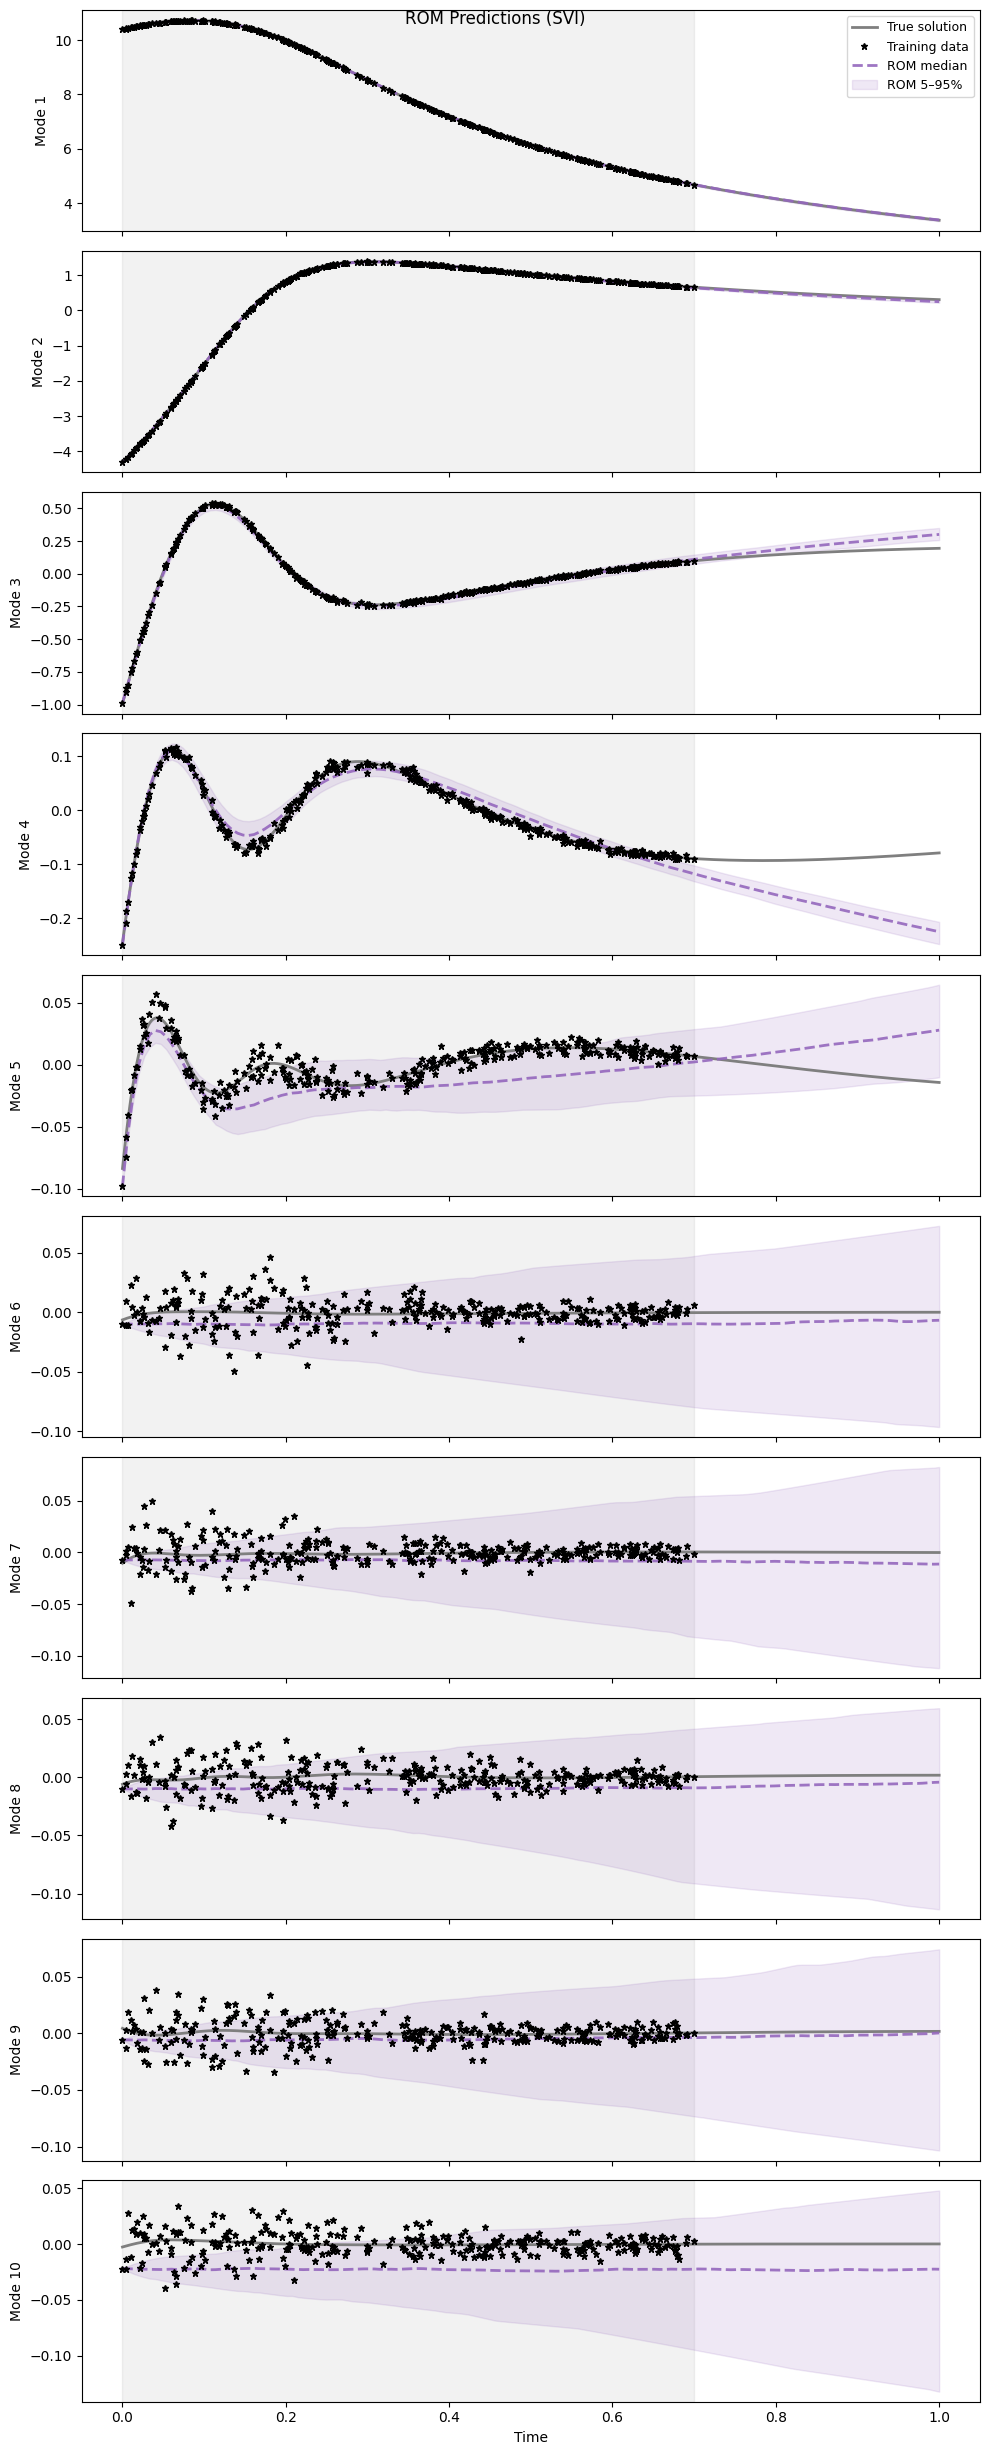

Stable prediction solves: 200


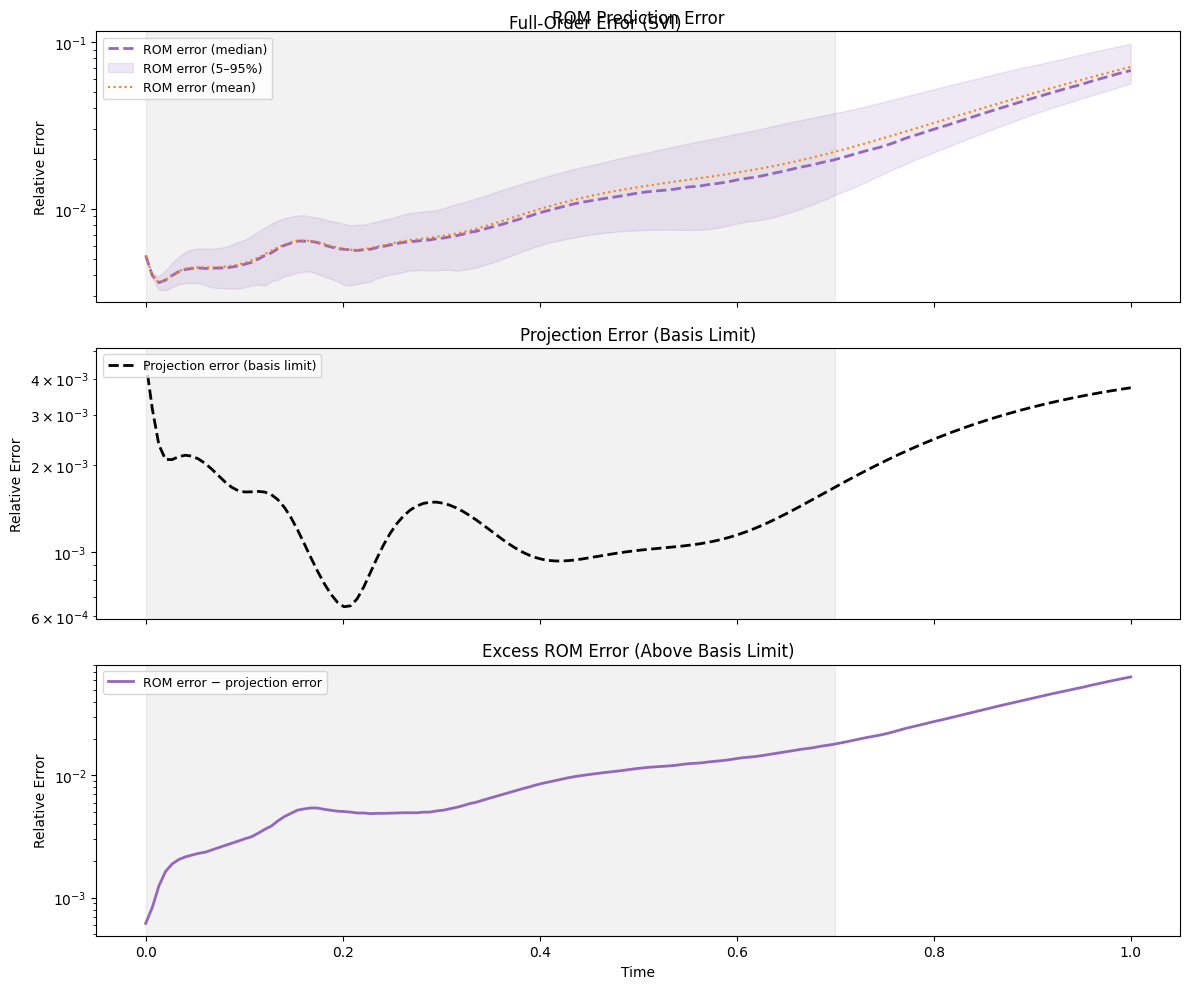

In [17]:
import time as time_module
svi_start_time = time_module.time()
if RUN_SVI:
    svi_Os, svi_rom_solves, svi_fig_rom, svi_fig_err = _evaluate_and_plot(svi_result.samples, "SVI")
    if SAVE_PAPER_FIGURES:
        save_paper_figure(svi_fig_rom, f"burgers_{PAPER_SCENARIO}_gp_bayes", PAPER_FIGURES_DIR)
        if svi_fig_err is not None:
            save_paper_figure(svi_fig_err, f"burgers_{PAPER_SCENARIO}_gp_bayes_error", PAPER_FIGURES_DIR)
total_plot_time += time_module.time() - svi_start_time

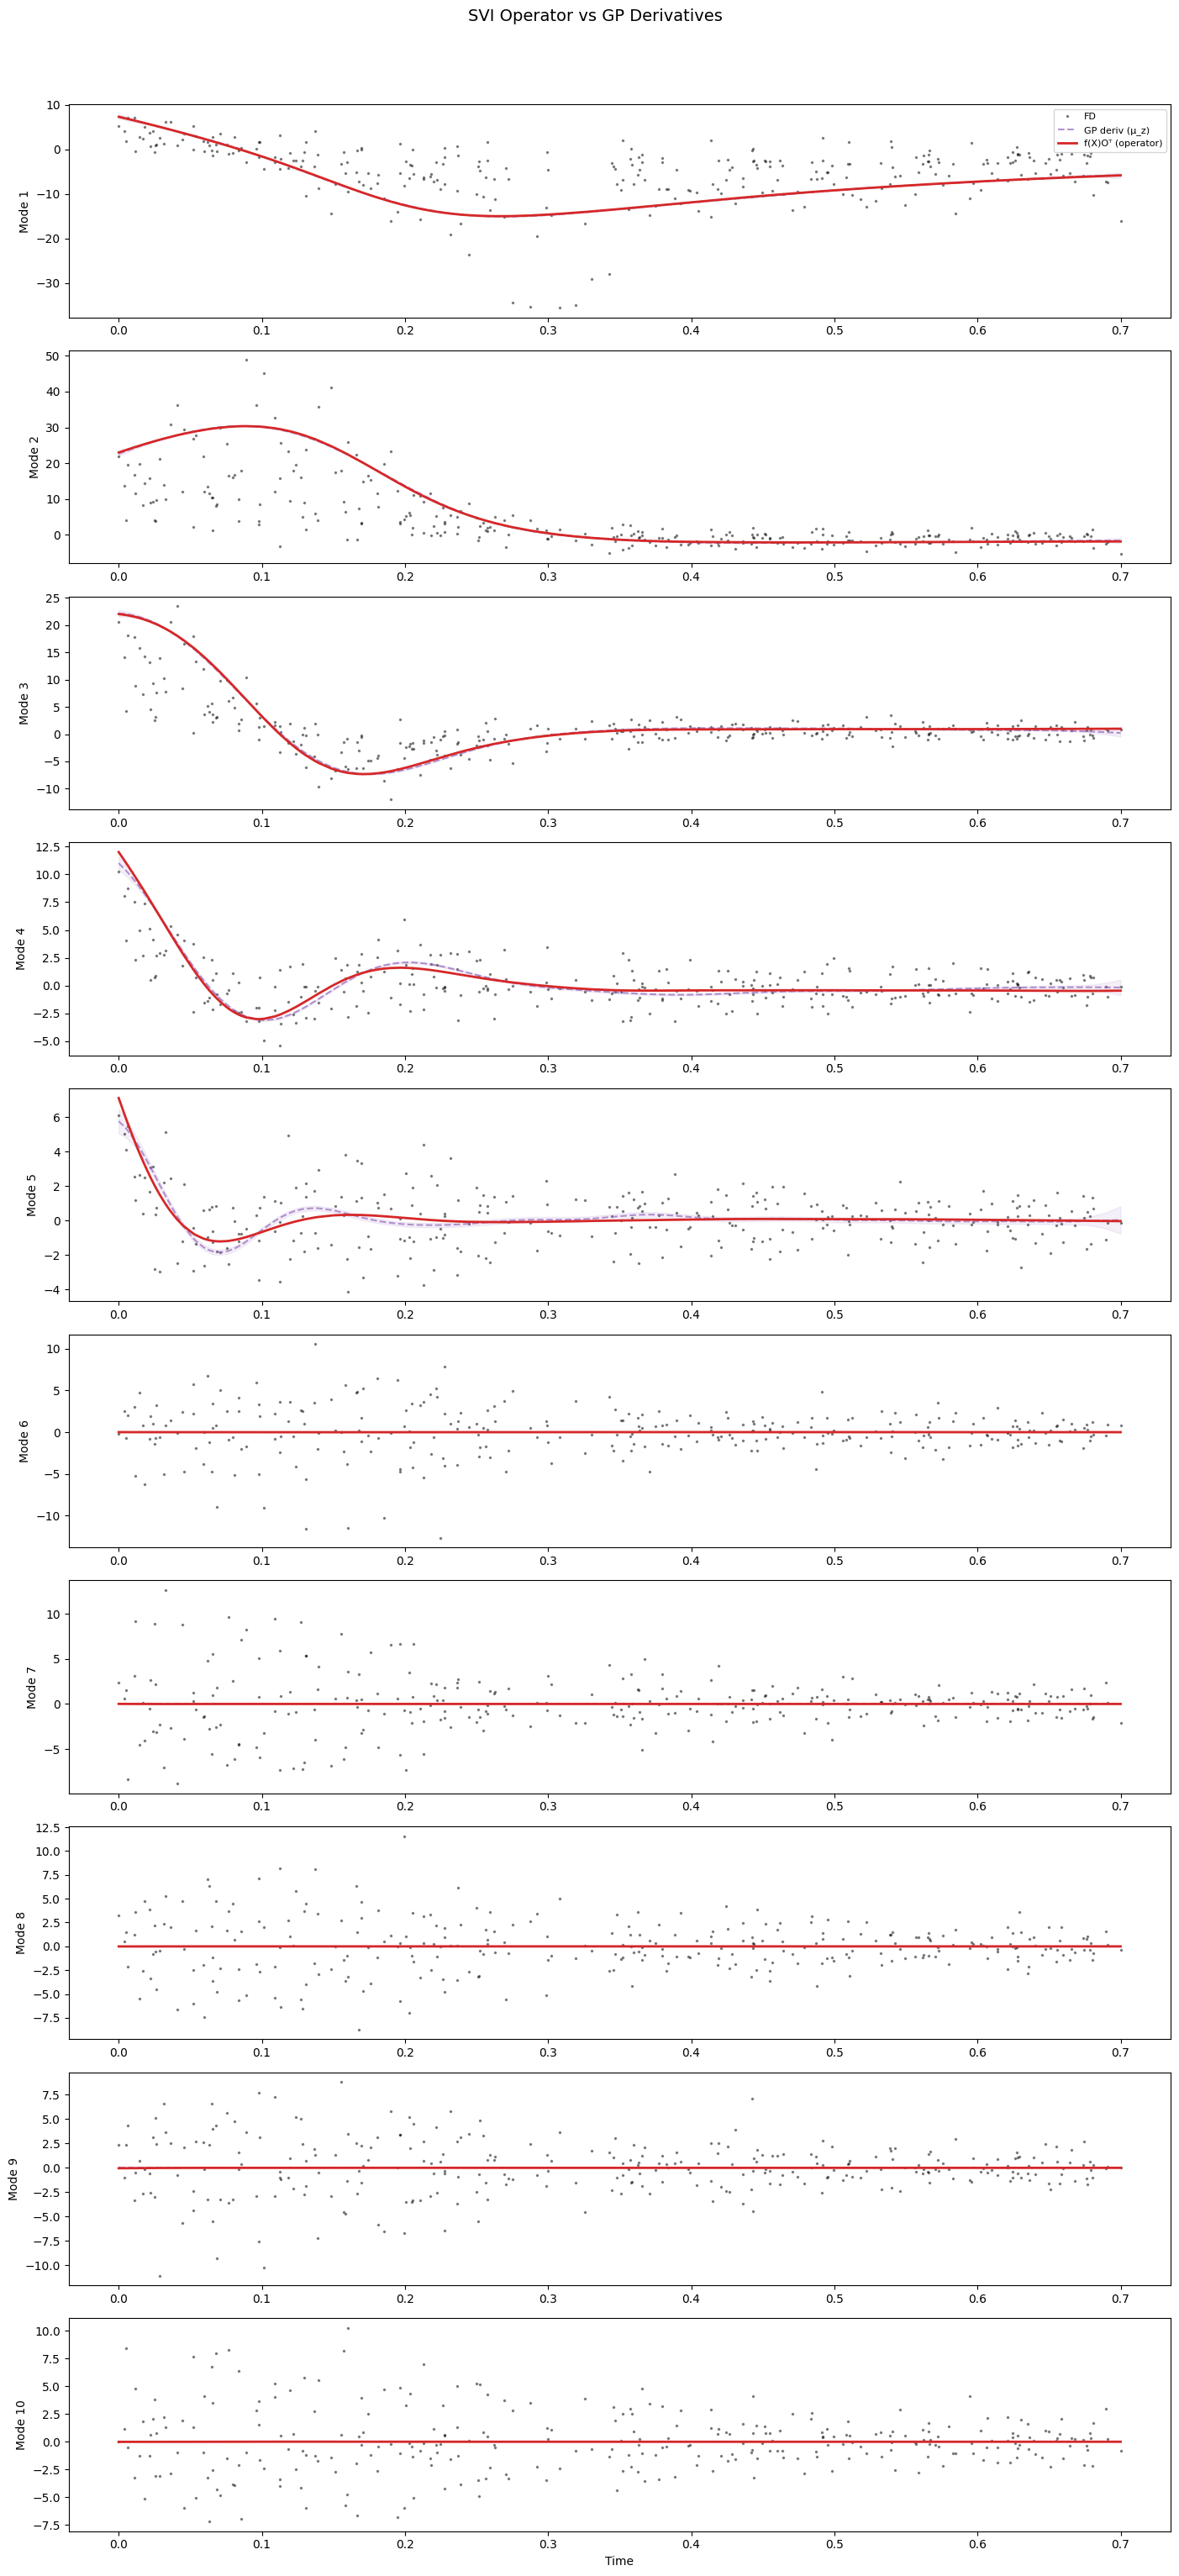

In [18]:
# Operator derivative fit diagnostic (SVI)
try:
    _O_mean = svi_Os.mean(axis=0)
    plot_operator_derivative_fit(
        operator=_O_mean,
        rom=rom,
        Xs_means=Xs_means,
        time_eval=time_eval,
        Ls=Ls, Vs=Vs,
        time_train=time_sampled,
        snapshots=training_data,
        Ns=Ns,
        inputs_eval=None,
        data_scaler=data_scaler if USE_SCALED_DATA else None,
        title="SVI Operator vs GP Derivatives",
    )
    plt.show()
except Exception as e:
    print(f"SVI derivative fit plot failed: {e}")

In [19]:
end_time = time.time()
algo_time = end_time - start_time - total_plot_time

print(f"Total wall time: {end_time - start_time:.1f}s")
print(f"Plot time excluded: {total_plot_time:.1f}s")
print(f"Algorithm runtime: {algo_time:.1f}s ({algo_time/60:.1f}min)")

Total wall time: 851.8s
Plot time excluded: 3.2s
Algorithm runtime: 848.5s (14.1min)


## 5. Summary

In [20]:
print("=" * 50)
print("EXPERIMENT SUMMARY: Burgers (GP-Bayesian)")
print("=" * 50)
print(f"Operators: {OPERATORS}")
print(f"Modes: {NUM_MODES}")
print(f"Training span: [{TRAINING_SPAN[0]}, {TRAINING_SPAN[1]}]")
print(f"Prediction span: [{PREDICTION_SPAN[0]}, {PREDICTION_SPAN[1]}]")
print(f"Scaling: {'enabled' if USE_SCALED_DATA else 'disabled'}")
print(f"GP-derivative operator: reg = {best_reg:.1e}, traj_err = {best_traj_err:.4f}")
print(f"Gamma (operator): {GAMMA}")
print(f"Gamma2 (ODE): {GAMMA2}")
print(f"Guide: {GUIDE.__name__}")
if RUN_SVI:
    print(f"\nSVI: {len(svi_Os)} operator samples, {len(svi_rom_solves)} stable solves")

EXPERIMENT SUMMARY: Burgers (GP-Bayesian)
Operators: cAH
Modes: 10
Training span: [0, 0.7]
Prediction span: [0, 1.0]
Scaling: disabled
GP-derivative operator: reg = 5.6e+00, traj_err = 0.0054
Gamma (operator): 0.1
Gamma2 (ODE): 0.1
Guide: AutoNormal

SVI: 200 operator samples, 200 stable solves


## 6. Diagnostics

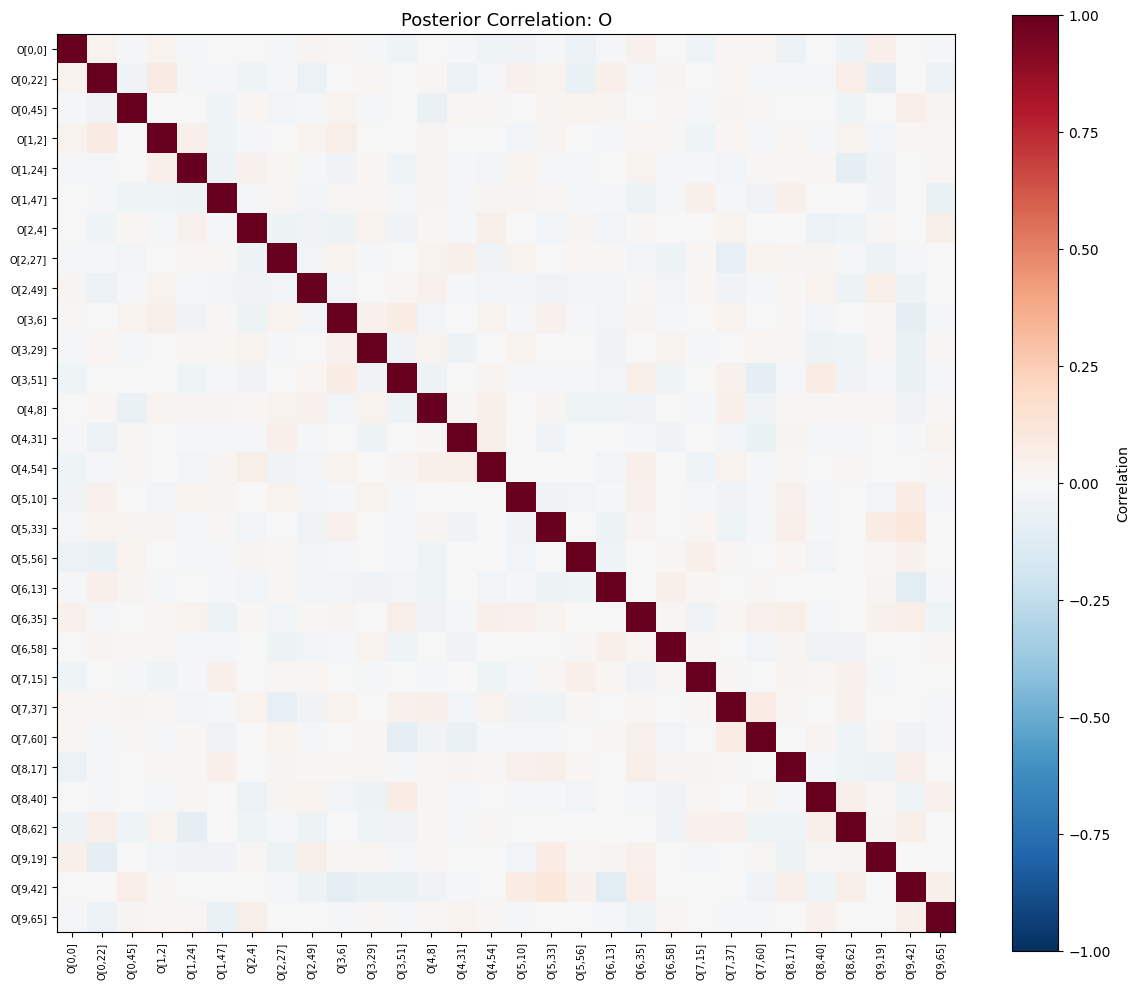

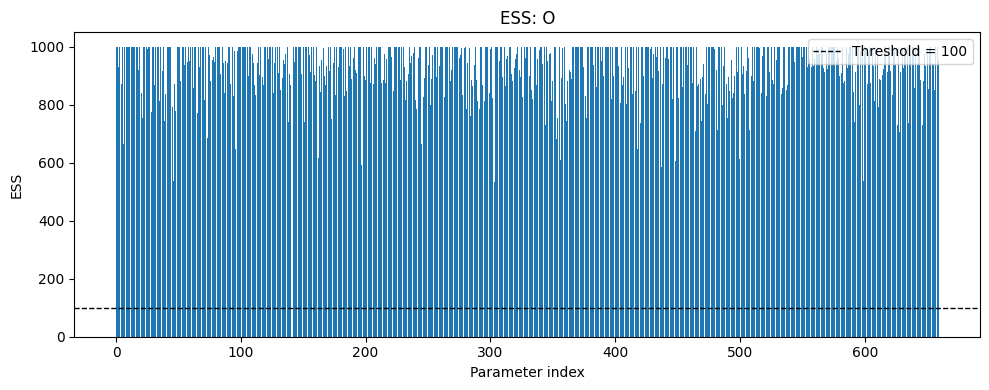

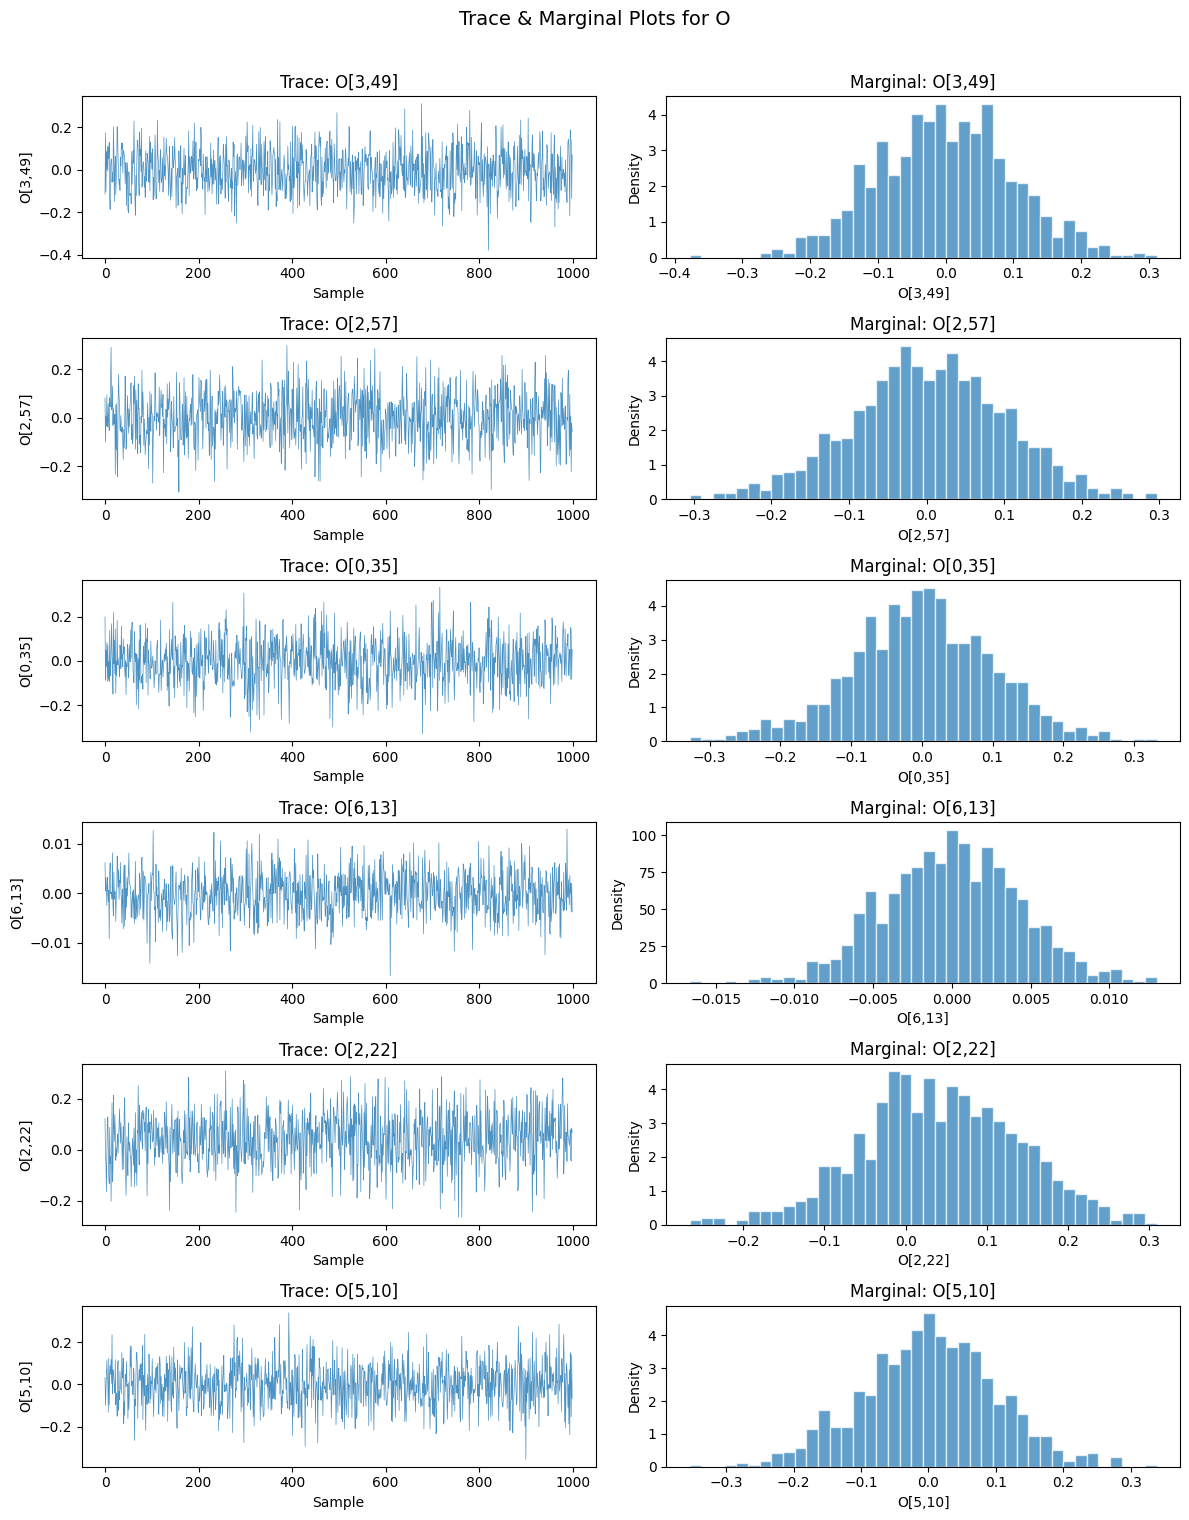

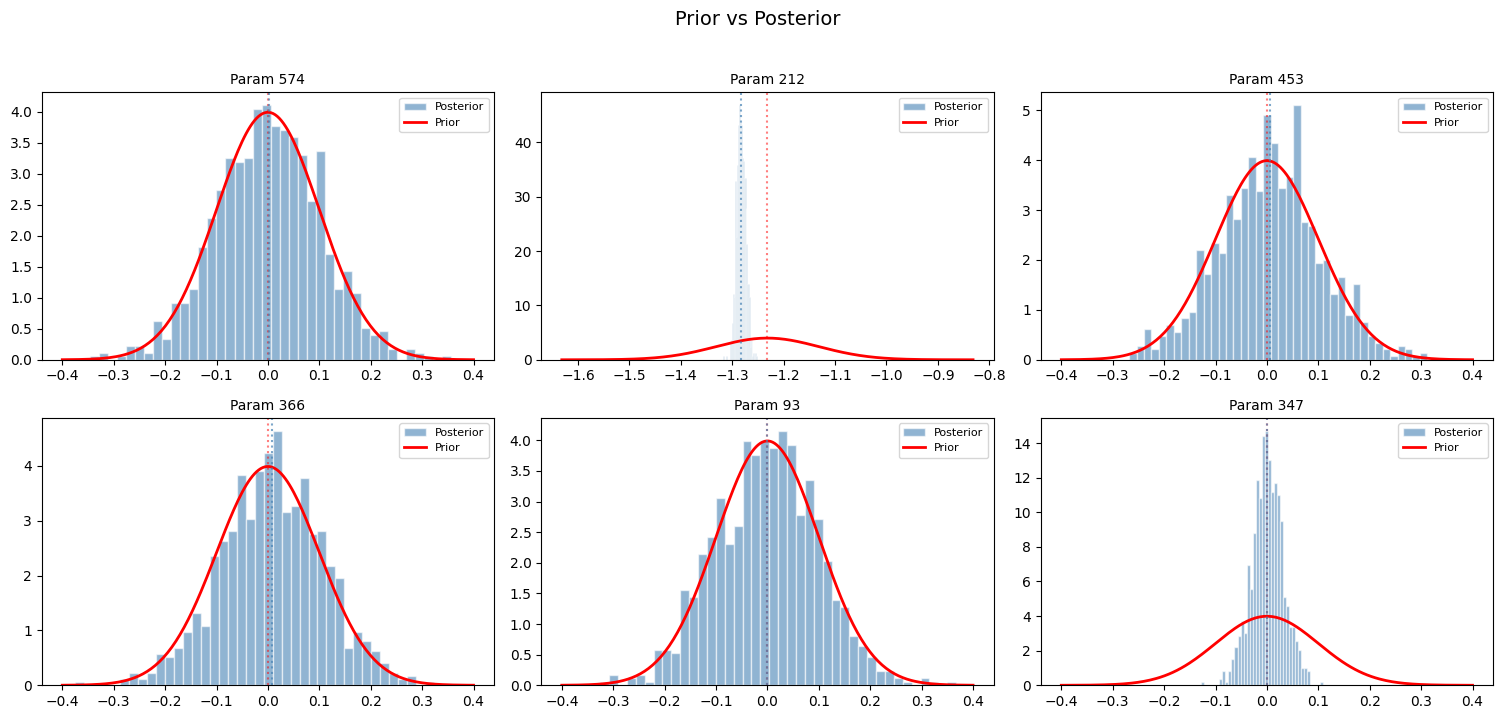

  BAYESIAN MODEL DIAGNOSTIC REPORT

--- Posterior Correlation ---
  No high correlations detected (|r| > 0.9).

--- Effective Sample Size (ESS) ---
  Min ESS:  533.3
  Mean ESS: 940.5
  Max ESS:  1000.0

--- Prior-Posterior Overlap ---
  O[1,15]: overlap = 26.40% [OK]
  O[1,6]: overlap = 88.83% [OK]
  O[5,49]: overlap = 89.07% [OK]
  O[2,41]: overlap = 90.40% [CHECK]
  O[6,44]: overlap = 90.41% [CHECK]



In [21]:
diag_samples = svi_result.samples

diag_report = run_diagnostics(
    samples=diag_samples,
    param_name="O",
    prior_mean=prior_operator,
    prior_std=GAMMA,
    mcmc_result=None,
    samples_by_chain=None,
    correlation_threshold=0.9,
    ess_threshold=100,
    verbose=VERBOSE,
    plot=True,
)

  STABILITY DIAGNOSTIC REPORT

--- Operator Stability ---
  Prior operator:     STABLE
  Posterior MAP/mean: STABLE

--- ELBO Convergence ---
  Status: converged  (final slope = -3.07e-03)

--- Prior → Posterior Shift ---
  Mode 0: ‖ΔO‖ = 0.1033
  Mode 1: ‖ΔO‖ = 0.2211
  Mode 2: ‖ΔO‖ = 0.3385
  Mode 3: ‖ΔO‖ = 0.4942
  Mode 4: ‖ΔO‖ = 0.2426
  Mode 5: ‖ΔO‖ = 0.0519
  Mode 6: ‖ΔO‖ = 0.0585
  Mode 7: ‖ΔO‖ = 0.0584
  Mode 8: ‖ΔO‖ = 0.0556
  Mode 9: ‖ΔO‖ = 0.0625
  Per-block relative shift (‖Δblock‖/‖prior_block‖):
    c: 0.1428
    A: 0.1017
    H: 0.1411

--- Linear Operator (A) Eigenvalues ---
  Prior  max Re(λ): +0.025069  (unstable!)
  Post.  max Re(λ): +0.011975  (unstable!)

--- Perturbation Sensitivity ---
  Perturb c: ████████████████████ 100% stable
  Perturb A: ████████████████████ 100% stable
  Perturb H: ████████████████████ 100% stable

--- ⚠  Warnings ---
  • Posterior A has eigenvalue with Re(λ)=+0.0120 — linear dynamics are unstable.


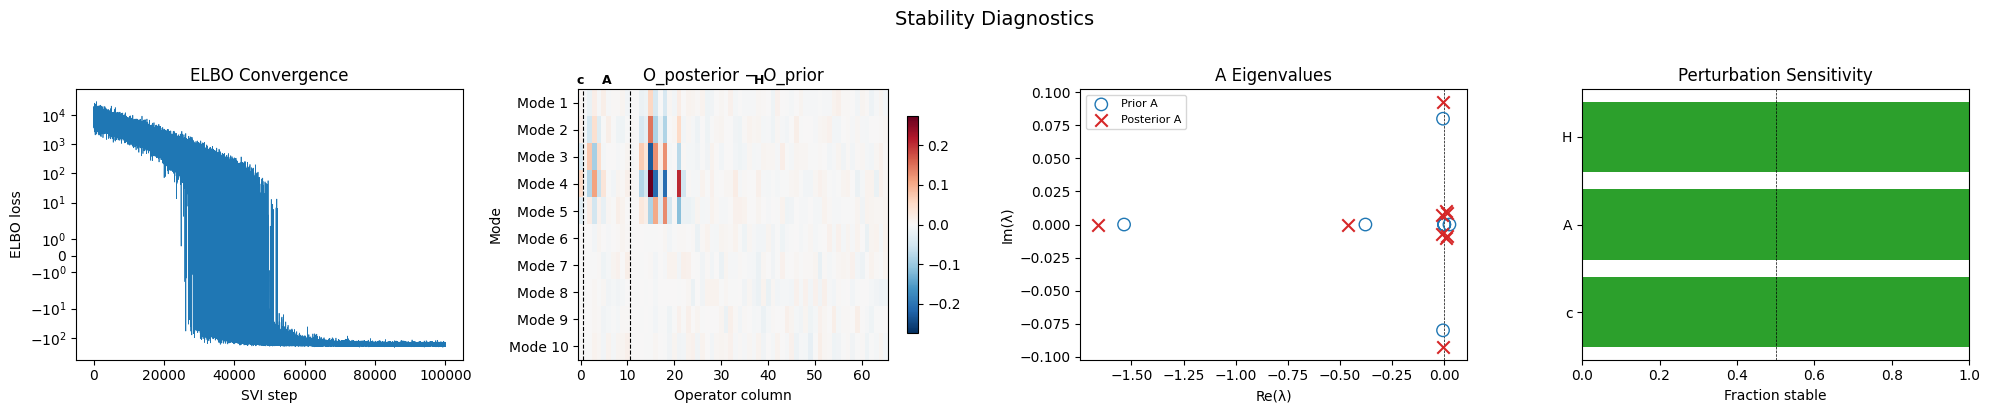

In [22]:
posterior_O = svi_Os.mean(axis=0)
stability_report = diagnose_stability(
    posterior_operator=posterior_O,
    prior_operator=prior_operator,
    rom=rom,
    snapshots_compressed=snapshots_comp_sampled,
    time_eval=time_domain_eval_prediction,
    operators=OPERATORS,
    input_func=None,
    input_dim=0,
    losses=svi_result.losses if RUN_SVI else None,
)